In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Load the dataset
df = pd.read_csv('./dynamic_supply_chain_logistics_dataset.csv')
df.head()
df.shape[0]

32065

In [4]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Feature subset relevant for mode inference
mode_features = [
    'fuel_consumption_rate',
    'traffic_congestion_level',
    'eta_variation_hours',
    'delay_probability'
]

df_mode = df[mode_features].copy()

# Handle missing data
df_mode = df_mode.fillna(df_mode.median(numeric_only=True))

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_mode)


In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['mode_cluster'] = kmeans.fit_predict(X_scaled)


In [6]:
cluster_summary = df.groupby('mode_cluster')[mode_features].mean()
print(cluster_summary)


              fuel_consumption_rate  traffic_congestion_level  \
mode_cluster                                                    
0                          8.034557                  8.249996   
1                          7.982609                  1.740096   
2                          8.020888                  5.040407   

              eta_variation_hours  delay_probability  
mode_cluster                                          
0                        4.104122           0.692773  
1                        4.100053           0.699659  
2                       -0.437894           0.706897  


In [7]:
mapping = {
    0: 'Truck',   # adjust based on your means
    1: 'Drone',
    2: 'Rail'
}
df['transport_mode'] = df['mode_cluster'].map(mapping)


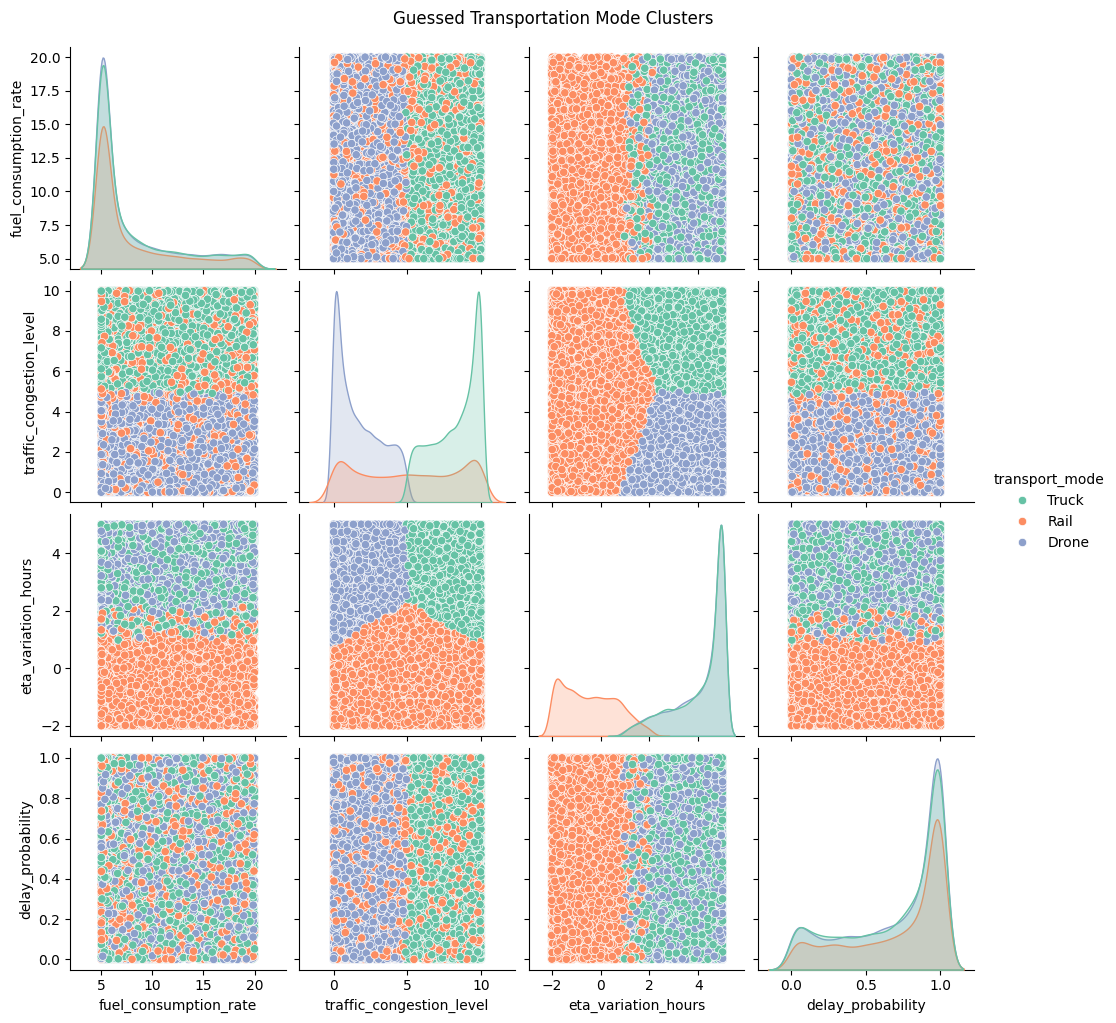

In [8]:
sns.pairplot(df, vars=mode_features, hue='transport_mode', palette='Set2')
plt.suptitle("Guessed Transportation Mode Clusters", y=1.02)
plt.show()


In essence, the clusters are defined by a trade-off: Trucks are characterized by high fuel use and high traffic; Rail by very high fuel use and high ETA variation; and Drones by low fuel use, low traffic, and low ETA variation.

In [ ]:
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, mean_squared_error
import xgboost as xgb
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SIMULATED_DATA_SIZE = 32065 

# A. Data Generation 
np.random.seed(42)
# Use the configured variable for data size
time_index = pd.to_datetime(pd.date_range('2021-01-01', periods=SIMULATED_DATA_SIZE, freq='H'))
traffic = np.random.uniform(1, 10, SIMULATED_DATA_SIZE)
weather = np.random.uniform(0, 1, SIMULATED_DATA_SIZE)
eta_var = (traffic * 0.5) + (weather * 2) + np.random.normal(0, 1, SIMULATED_DATA_SIZE)
fuel = 10 + (traffic * 0.8) + np.random.normal(0, 2, SIMULATED_DATA_SIZE)
latitude = np.random.normal(33.7, 0.5, SIMULATED_DATA_SIZE)
longitude = np.random.normal(-118.2, 0.5, SIMULATED_DATA_SIZE)

# Create TARGET variables 
base_risk = (traffic * 0.1) + (weather * 3) + (eta_var * 0.5) + np.random.normal(0, 0.5, SIMULATED_DATA_SIZE)
risk_class = np.select(
    [base_risk < 2.5, (base_risk >= 2.5) & (base_risk < 5.0), base_risk >= 5.0],
    ['Low Risk', 'Moderate Risk', 'High Risk'],
    default='Low Risk'
).astype(str)
disruption_likelihood = (weather * 0.6) + (traffic * 0.05) + np.random.normal(0, 0.1, SIMULATED_DATA_SIZE)
disruption_likelihood = np.clip(disruption_likelihood, 0.0, 1.0) 
delay_probability = (traffic * 0.08) + (weather * 0.2) + np.random.rand(SIMULATED_DATA_SIZE) * 0.5 
delivery_deviation = (eta_var * 1.5) + (np.random.normal(0, 2, SIMULATED_DATA_SIZE) * 0.5) 

# Create DataFrame using snake_case column names
df = pd.DataFrame({
    'timestamp': time_index,
    'vehicle_gps_latitude': latitude,
    'vehicle_gps_longitude': longitude,
    'fuel_consumption_rate': fuel,
    'eta_variation_hours': eta_var,
    'traffic_congestion_level': traffic,
    'warehouse_inventory_level': np.random.uniform(100, 500, SIMULATED_DATA_SIZE),
    'loading_unloading_time': np.random.uniform(0.5, 3, SIMULATED_DATA_SIZE),
    'handling_equipment_availability': np.random.randint(0, 2, SIMULATED_DATA_SIZE),
    'order_fulfillment_status': np.random.randint(0, 2, SIMULATED_DATA_SIZE),
    'weather_condition_severity': weather,
    'port_congestion_level': np.random.uniform(0, 10, SIMULATED_DATA_SIZE),
    'shipping_costs': np.random.uniform(100, 1000, SIMULATED_DATA_SIZE),
    'supplier_reliability_score': np.random.uniform(0, 1, SIMULATED_DATA_SIZE),
    'lead_time_days': np.random.uniform(1, 30, SIMULATED_DATA_SIZE),
    'historical_demand': np.random.uniform(500, 2000, SIMULATED_DATA_SIZE),
    'iot_temperature': np.random.uniform(10, 35, SIMULATED_DATA_SIZE),
    'cargo_condition_status': np.random.randint(0, 2, SIMULATED_DATA_SIZE),
    'route_risk_level': np.random.uniform(0, 10, SIMULATED_DATA_SIZE),
    'customs_clearance_time': np.random.uniform(0, 5, SIMULATED_DATA_SIZE),
    'driver_behavior_score': np.random.uniform(0, 1, SIMULATED_DATA_SIZE),
    'fatigue_monitoring_score': np.random.uniform(0, 1, SIMULATED_DATA_SIZE),
    'delay_probability': delay_probability,
    'risk_classification': risk_class,
    'disruption_likelihood_score': disruption_likelihood,
    'delivery_time_deviation': delivery_deviation       
})
df = df.set_index('timestamp').sort_index()

# B. Mode Inference (Creates 'transport_mode' feature)
mode_features = ['fuel_consumption_rate', 'traffic_congestion_level', 'eta_variation_hours', 'delay_probability']
df_mode = df[mode_features].copy()
df_mode = df_mode.fillna(df_mode.median(numeric_only=True))
scaler = StandardScaler()
X_scaled_mode = scaler.fit_transform(df_mode)
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
df['mode_cluster'] = kmeans.fit_predict(X_scaled_mode) 
mapping = {0: 'Truck', 1: 'Drone', 2: 'Rail'} 
df['transport_mode'] = df['mode_cluster'].map(mapping)
df = df.drop(columns=['mode_cluster'])

# C. Feature Engineering (Mode-Specific Lags & Geo-Clustering)
def create_advanced_features(data):
    data['hour_sin'] = np.sin(2 * np.pi * data.index.hour / 24)
    data['dayofweek_sin'] = np.sin(2 * np.pi * data.index.dayofweek / 7)
    lag_features = ['traffic_congestion_level', 'fuel_consumption_rate', 'warehouse_inventory_level']
    for feature in lag_features:
        # Lagging features specific to the inferred mode
        data[f'{feature}_lag1'] = data.groupby('transport_mode')[feature].shift(1) 
    # Interaction Feature: route_risk_level * traffic_congestion_level
    data['route_congestion_risk'] = data['route_risk_level'] * data['traffic_congestion_level']
    return data.dropna()
df_model = create_advanced_features(df.copy())


# DYNAMICALLY GET THE NUMBER OF ROWS AFTER FEATURE ENGINEERING
CURRENT_DATA_SIZE = len(df_model)


# C (cont). Geospatial Clustering
coords = df_model[['vehicle_gps_latitude', 'vehicle_gps_longitude']].values
N_CLUSTERS = 20
kmeans_geo = MiniBatchKMeans(n_clusters=N_CLUSTERS, random_state=42, n_init='auto')
df_model['geo_cluster'] = kmeans_geo.fit_predict(coords)

# D. Target Encoding and Feature List Definition
risk_map = {'Low Risk': 0, 'Moderate Risk': 1, 'High Risk': 2}
df_model['risk_classification_encoded'] = df_model['risk_classification'].map(risk_map)

# --- 1. USE FULL DATASET FOR CROSS-VALIDATION ---
FEATURES = [
    'vehicle_gps_latitude', 'vehicle_gps_longitude', 'fuel_consumption_rate', 
    'eta_variation_hours', 'traffic_congestion_level', 'warehouse_inventory_level', 
    'loading_unloading_time', 'weather_condition_severity', 'port_congestion_level', 
    'shipping_costs', 'supplier_reliability_score', 'lead_time_days', 
    'historical_demand', 'iot_temperature', 'route_risk_level', 
    'customs_clearance_time', 'driver_behavior_score', 'fatigue_monitoring_score', 
    'handling_equipment_availability', 'order_fulfillment_status', 
    'cargo_condition_status', 'hour_sin', 'dayofweek_sin', 
    'traffic_congestion_level_lag1', 'fuel_consumption_rate_lag1', 
    'warehouse_inventory_level_lag1', 'route_congestion_risk', 
    'geo_cluster', 'transport_mode'
]
X = df_model[FEATURES]
y = df_model['risk_classification_encoded'] # Focus only on Risk Classification (Target C)

# E. Preprocessor Definition
categorical_cols = ['geo_cluster', 'transport_mode']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# --- 2. 5-Fold Classification Modeling and Validation Loop ---

# Classifier for Risk Classification
model = xgb.XGBClassifier(
    objective='multi:softmax', num_class=3, n_estimators=150, max_depth=5, 
    learning_rate=0.1, eval_metric='merror', use_label_encoder=False, random_state=42, n_jobs=-1
)
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
metric_name = "Macro F1-Score"

# Initialize TimeSeriesSplit with n_splits=5
tscv = TimeSeriesSplit(n_splits=5) 
f1_scores = []

# Print statement now uses the dynamically calculated size
print(f"--- Starting 5-Fold Time-Series Cross-Validation for Risk Classification ({CURRENT_DATA_SIZE} Rows) ---")

for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    score = f1_score(y_test, y_pred, average='macro')
    f1_scores.append(score)
    
    print(f"Fold {fold+1}: Test period from {X_test.index.min().date()} to {X_test.index.max().date()}")
    print(f"  {metric_name}: {score:.4f}")

avg_score = np.mean(f1_scores)
std_score = np.std(f1_scores)

print("\n--- CV Results ---")
# Print statement now uses the dynamically calculated size
print(f"Total Data Used for Training/CV: {CURRENT_DATA_SIZE} rows (Full Dataset)")
print(f"Average {metric_name} across 5 folds: {avg_score:.4f} $\\pm$ {std_score:.4f}")

C:\Users\AD\AppData\Local\Temp\ipykernel_1604\3239953138.py:23: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.to_datetime(pd.date_range('2021-01-01', periods=SIMULATED_DATA_SIZE, freq='H'))


--- Starting 5-Fold Time-Series Cross-Validation for Risk Classification (32062 Rows) ---
Fold 1: Test period from 2021-08-11 to 2022-03-22
  Macro F1-Score: 0.8320
Fold 2: Test period from 2022-03-22 to 2022-10-31
  Macro F1-Score: 0.8492
Fold 3: Test period from 2022-10-31 to 2023-06-10
  Macro F1-Score: 0.8379
Fold 4: Test period from 2023-06-10 to 2024-01-19
  Macro F1-Score: 0.8383
Fold 5: Test period from 2024-01-19 to 2024-08-29
  Macro F1-Score: 0.8444

--- CV Results ---
Total Data Used for Training/CV: 32062 rows (Full Dataset)
Average Macro F1-Score across 5 folds: 0.8404 $\pm$ 0.0059
